# Practical Work: Out-of-Distribution Detection, OOD Scoring Methods, and Neural Collapse

In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# Question 1. Train a ResNet-18 classifier on CIFAR-100 using PyTorch.

In [2]:
# Import the model and the data
model = models.resnet18(weights=None)

train_transform = transforms.Compose([ # Data augmentation
    transforms.RandomCrop(32, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
])
train_data = datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

# Create dataloaders
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=1024, shuffle=False, num_workers=2)

# Change the output layer of the model, so that its output is of size 100
classes = len(train_data.classes) # should be 100
model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=classes,
    bias=True
)

100%|██████████| 169M/169M [00:13<00:00, 12.3MB/s]


ResNet-18 is designed for images of size 224x224 and its first later uses a 7x7 convolution. But CIFAR-100 images have size 32x32. Thus, we need to modify the first layer of ResNet in order to not loose the spatial information to quickly.

In [3]:
model.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
model.maxpool = nn.Identity()

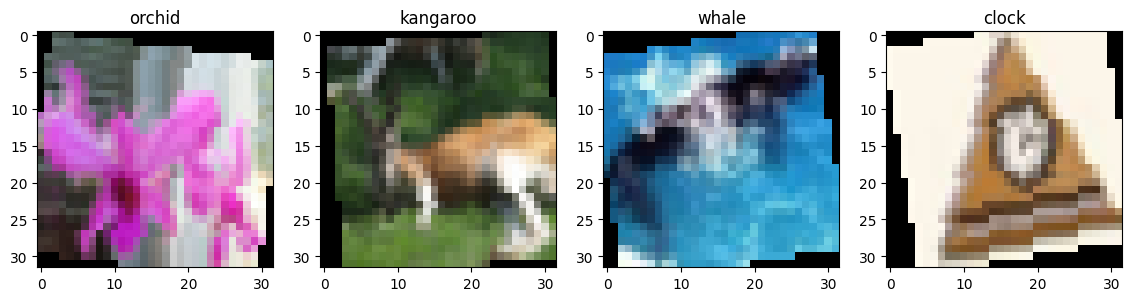

In [4]:
# Visualize 4 images from the training dataset

fig, axs = plt.subplots(1, 4, figsize=(14,4))

images, labels = next(iter(train_loader))
for i in range(4):
    axs[i].imshow(images[i].permute(1,2,0).numpy())
    axs[i].set_title(train_data.classes[labels[i]])

We now define the evaluate function

In [5]:
def evaluate(model, data_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    running_loss, running_acc = 0., 0.
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs, 1)
            running_acc += torch.sum(preds == labels).detach().cpu().numpy()
    return running_loss/len(data_loader.dataset), running_acc/len(data_loader.dataset)

# The untrained model should have around 1% accuracy on the training dataset
loss, accuracy = evaluate(model, train_loader)
print(f"Loss: {loss:.2f}, Accuracy: {accuracy*100:.1f}%")

Loss: 4.69, Accuracy: 1.0%


And finally train our model for 100 epochs.

In [6]:
# MODEL TRAINING
num_epochs = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = model.to(device)
criterion = nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.SGD(model.parameters(), lr=7e-4, momentum=0.9, weight_decay=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[55, 85], gamma=0.1)

training_loss, test_loss = np.zeros(num_epochs), np.zeros(num_epochs)
training_accuracy, test_accuracy = np.zeros(num_epochs), np.zeros(num_epochs)

for epoch in tqdm(range(num_epochs)):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()

    # We keep track of the training loss and test loss at each epoch
    training_loss[epoch], training_accuracy[epoch] = evaluate(model, train_loader)
    test_loss[epoch], test_accuracy[epoch] = evaluate(model, test_loader)

Device: cuda


100%|██████████| 100/100 [1:40:57<00:00, 60.58s/it]


In [7]:
print(f"Final training accuracy: {training_accuracy[-1]*100:.2f} %")
print(f"Final test accuracy: {test_accuracy[-1]*100:.2f} %")

Final training accuracy: 99.93 %
Final test accuracy: 71.23 %


Let us now plot the loss and the accuracy on both the training and test sets for each epoch.

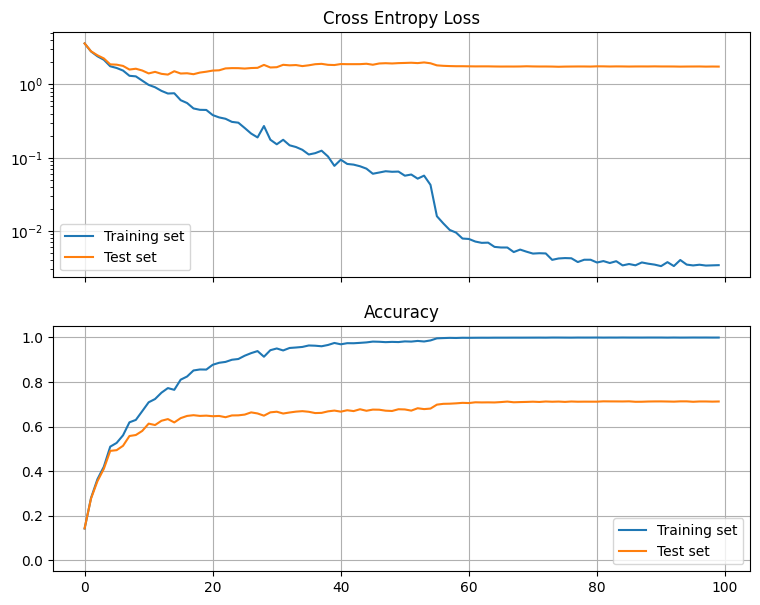

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(9,7), sharex=True)
axs[0].plot(training_loss, label="Training set")
axs[0].plot(test_loss, label="Test set")
axs[0].legend()
axs[0].set_title('Cross Entropy Loss')
axs[0].set_yscale('log')
axs[0].grid()

axs[1].plot(training_accuracy, label="Training set")
axs[1].plot(test_accuracy, label="Test set")
axs[1].legend()
axs[1].set_title('Accuracy')
axs[1].set_ylim((-0.05, 1.05))
axs[1].grid()

plt.show()

For the test accuracy, we reach 71.23% accuracy, which is quite good for CIFAR-100, even if it does not reach state-of-the-art. This will allow us to study out-of distribution detection in the next questions.

We observe sharp increases in accuracy at epochs 55 and 85. This confirms that dropping the learning rate using the `MultiStepLR` scheduler allowed the model to reach better local minima.

The training accuracy hits 0.999 around epoch 60 and stays there for the last 40 steps. This is a good thing, as we have a long stable terminal phase of training, which is necessary for studying Neural Collapse.

Finally, we save our model parameters.

In [9]:
path = 'resnet18_cifar100_final.pth'
torch.save(model.state_dict(), path)

# Questions 2 and 3: Evaluate several Out-of-Distribution (OOD) detection methods using the OpenOOD benchmark.

We evaluate several OOD detection methods, trying to reproduce the results of Zhang, et. al. (2024). We implement evaluation functions and each method: MSP, MaxLogits, Mahalanobis, Energy Score and ViM. Then, for each method, we evaluate it using the ResNet classifier trained in question 1, on two OOD datasets: a Far-OOD dataset (SVHN) and a near-OOD dataset (CIFAR-10). For each experiment, we plot the ROC curve of each method, and compare their AUROC score.

In [10]:
## ----- LOAD THE DATASETS -----

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# For the ID dataset, we use the CIFAR-100 test dataset
id_set = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
id_loader = DataLoader(id_set, batch_size=1024, shuffle=False, num_workers=2)

# For the OOD datasets, we will use CIFAR-10 as a "near Out-of-Distribution" dataset
# and SVHN as a "far Out-of-Distribution" dataset
near_ood_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
near_ood_loader = DataLoader(near_ood_set, batch_size=1024, shuffle=False, num_workers=2)
far_ood_set = datasets.SVHN(root='./data', split='test', download=True, transform=transform)
far_ood_loader = DataLoader(far_ood_set, batch_size=1024, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:10<00:00, 16.0MB/s]
100%|██████████| 170M/170M [00:11<00:00, 15.5MB/s]
100%|██████████| 64.3M/64.3M [00:24<00:00, 2.67MB/s]


In [11]:
## ----- EVALUATE MAIN FUNCTIONS -----

def compute_scores(model, loader, method):
    '''Compute the scores defined by the method function of the model on the given dataset.
    Args:
        model: the model to evaluate
        loader: DataLoader containing the dataset (id or ood)
        method: A function that takes logits and returns scores.
    Returns:
        scores: An array of the scores for the dataset.
    '''
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # We add a hook to access features
    activations = {}
    def get_activation():
        def hook(model, input, output):
            activations["features"] = output.detach().squeeze(-1).squeeze(-1)
        return hook
    hook_handle = model.avgpool.register_forward_hook(get_activation())

    scores = []
    with torch.no_grad():
        for inputs, _ in tqdm(loader):
            inputs = inputs.to(device)
            logits = model(inputs)
            features = activations["features"]
            scores.append(method(logits, features).detach().cpu().numpy())
    hook_handle.remove()

    return np.concatenate(scores)


def evaluate_ood_detection(model, id_loader, ood_loader, method, visualize_roc=False, ax=None):
    '''Evaluate the model and the scoring method by computing the scores for both the ID
    dataset and the OOD datasets, and computing the AUROC score and the FPR@95 score.
    If visualize_roc is true, plot the ROC curve on ax.'''

    id_scores = compute_scores(model, id_loader, method)
    ood_scores = compute_scores(model, ood_loader, method)

    # Ground truth labels, 1 is ID, 0 is OOD
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    # Predicted scores
    y_score = np.concatenate([id_scores, ood_scores])

    AUROC_score = roc_auc_score(y_true, y_score)

    # Compute FPR@95 score: false positive rate at 95% true positive rate
    fpr, tpr, _ = roc_curve(y_true, y_score)
    FPR95_score = fpr[np.where(tpr >= .95)[0][0]]

    if visualize_roc:
        RocCurveDisplay.from_predictions(y_true, y_score, ax=ax, label=method.__name__)

    return AUROC_score, FPR95_score

In [12]:
# ----- SCORING METRICS -----

def msp(logits, features):
    probas = F.softmax(logits, dim=1)
    return torch.max(probas, dim=1).values

def max_logit(logits, features):
    return torch.max(logits, dim=1).values

def energy_score(logits, features, T=1.0):
    return T * torch.logsumexp(logits / T, dim=1)

In [13]:
## ----- MAHALANOBIS DISTANCE -----
# To compute the Mahalanobis distance, we need to have access to a features space
# (we will use the penultimate layer), and to compute the class mean and covariance
# in this feature space.

training_samples = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
training_samples_loader = DataLoader(training_samples, batch_size=1024, shuffle=False, num_workers=2)

C = model.fc.out_features # number of classes
p = model.fc.in_features # size of features space
N = len(training_samples)

# We add a hook on the model so that we can access features
activations = {}
def get_activation():
    def hook(model, input, output):
        activations["features"] = output.detach().squeeze(-1).squeeze(-1)
    return hook
hook_handle = model.avgpool.register_forward_hook(get_activation())

# RUN ON ALL THE TRAINING DATASET AND KEEP USEFUL FEATURES STATISTICS
Nc = torch.zeros((C), device=device) # count number of examples in each class
sum_h = torch.zeros((C, p), device=device) # sum over i of h_{i,c} for each class
sum_hhT = torch.zeros((p, p), device=device) # sum over i and c of h_{i,c} h_{i,c}^\top

with torch.no_grad():
    for inputs, labels in tqdm(training_samples_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        model(inputs)
        features = activations["features"]

        Nc.index_add_(0, labels, torch.ones(labels.shape, device=device))
        sum_h.index_add_(0, labels, features)
        sum_hhT += torch.sum(features[:,:,None] * features[:,None,:], dim=0)
hook_handle.remove()

CLASS_MEANS = sum_h / Nc[:, None]
COVARIANCE_MATRIX = 1/N * sum_hhT - 1/N * torch.sum(Nc[:,None,None] * CLASS_MEANS[:,:,None] * CLASS_MEANS[:,None,:], dim=0)
INVERSE_COVARIANCE_MATRIX = torch.linalg.inv(COVARIANCE_MATRIX + 1e-8 * torch.eye(p, device=device))

# We can now define the Mahalanobis distance

def mahalanobis_distance(logits, features):
    per_class_diff_to_center = features[:, None, :] - CLASS_MEANS[None, :, :]
    per_class_distance = per_class_diff_to_center[:,:,None,:] @ INVERSE_COVARIANCE_MATRIX[None,None,:,:] @ per_class_diff_to_center[:,:,:,None]
    per_class_distance = per_class_distance.squeeze(-1).squeeze(-1)
    mahalanobis_score = torch.min(per_class_distance, dim=1).values
    return - mahalanobis_score

100%|██████████| 49/49 [00:12<00:00,  3.85it/s]


In [14]:
# ----- ViM -----
# We now implement the ViM score, from Wang et. al. (2022)

# COMPUTE PCA TO DEFINE MATRIX R
glob_mean = 1/N * torch.sum(sum_h, dim=0)
glob_cov_mat = 1/N * sum_hhT - glob_mean[:, None] * glob_mean[None, :]
eigenvalues, eigenvectors = torch.linalg.eigh(glob_cov_mat)
D = 100
R = eigenvectors[:, :-D]

# WE GO THROUGH THE TRAINING SET A SECOND TIME TO COMPUTE ALPHA
hook_handle = model.avgpool.register_forward_hook(get_activation())
sum_residuals = 0.
sum_energy = 0.

with torch.no_grad():
    for inputs, _ in tqdm(training_samples_loader):
        inputs = inputs.to(device)
        logits = model(inputs)
        features = activations["features"]

        # Calculate Residuals
        features_centered = features - glob_mean[None, :]
        projection = features_centered @ R
        residuals_norm = torch.norm(projection, dim=1)
        sum_residuals += torch.sum(residuals_norm).item()

        # Calculate energy
        sum_energy += torch.sum(torch.max(logits, dim=1).values).item()
hook_handle.remove()

ALPHA = sum_energy / sum_residuals

# We can now define the ViM score function

def vim(logits, features):
    features_centered = features - glob_mean[None, :]
    projection = features_centered @ R
    residuals_norm = torch.norm(projection, dim=1)
    energy_score = torch.logsumexp(logits, dim=1)
    return - ALPHA * residuals_norm + energy_score

100%|██████████| 49/49 [00:13<00:00,  3.62it/s]


100%|██████████| 10/10 [00:02<00:00,  3.63it/s]


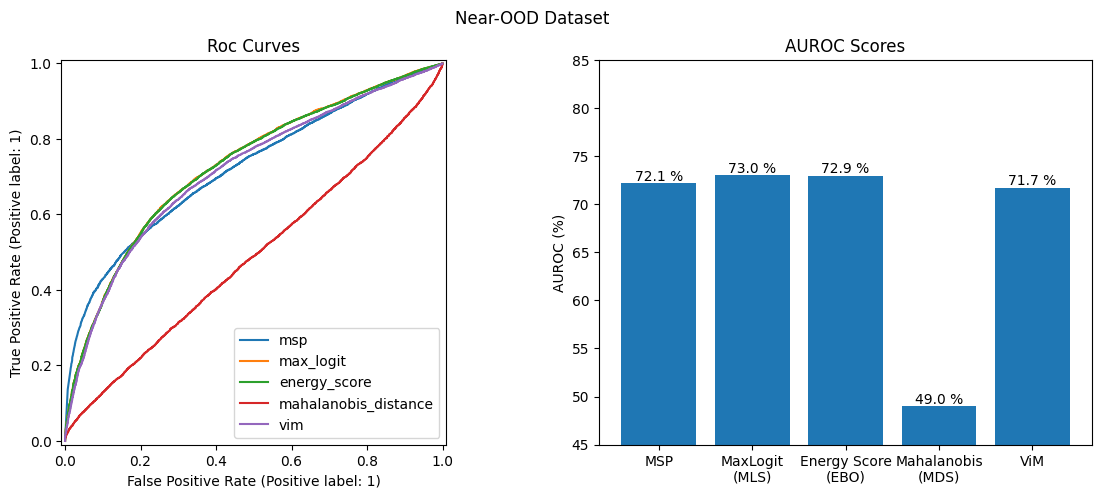

In [15]:
# ----- METHODS EVALUATION ----

# We first evaluate on the NEAR OOD DATASET: CIFAR-10

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

aurocs = []
fpr95s = []
for method in [msp, max_logit, energy_score, mahalanobis_distance, vim]:
    auroc, fpr95 = evaluate_ood_detection(model, id_loader, near_ood_loader, method, visualize_roc=True, ax=axs[0])
    aurocs.append(auroc)
    fpr95s.append(fpr95)
axs[0].set_title("Roc Curves")

bars = axs[1].bar(["MSP", "MaxLogit\n(MLS)", "Energy Score\n(EBO)", "Mahalanobis\n(MDS)", "ViM"], np.array(aurocs)*100)
for (i, bar) in enumerate(bars): plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{aurocs[i]*100:.1f} %", ha='center', va='bottom')
axs[1].set_ylabel("AUROC (%)")
axs[1].set_ylim((45, 85))
axs[1].set_title("AUROC Scores")

fig.suptitle("Near-OOD Dataset")
plt.show()

100%|██████████| 26/26 [00:07<00:00,  3.35it/s]


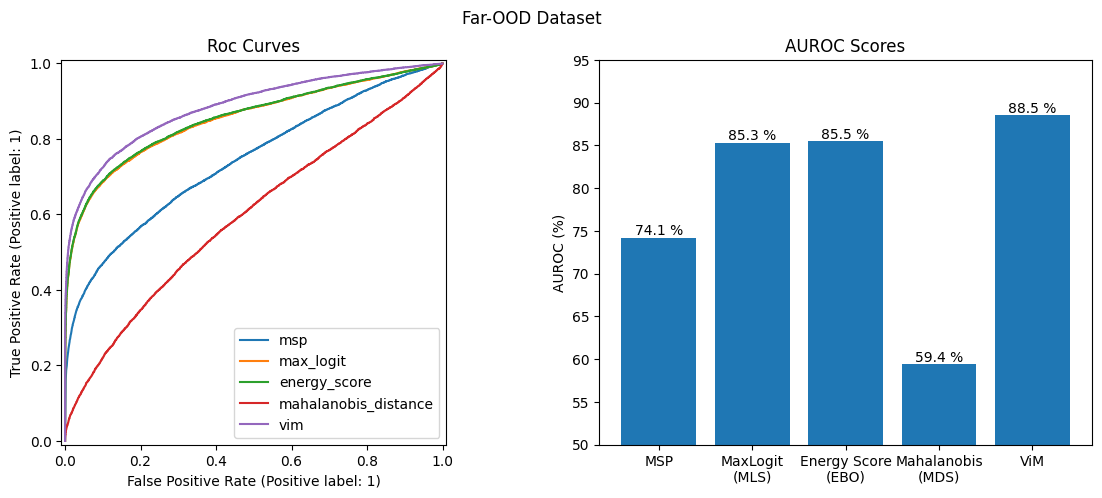

In [16]:
# FAR OOD DATASET: SVHN

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

aurocs = []
fpr95s = []
for method in [msp, max_logit, energy_score, mahalanobis_distance, vim]:
    auroc, fpr95 = evaluate_ood_detection(model, id_loader, far_ood_loader, method, visualize_roc=True, ax=axs[0])
    aurocs.append(auroc)
    fpr95s.append(fpr95)
axs[0].set_title("Roc Curves")

bars = axs[1].bar(["MSP", "MaxLogit\n(MLS)", "Energy Score\n(EBO)", "Mahalanobis\n(MDS)", "ViM"], np.array(aurocs)*100)
for (i, bar) in enumerate(bars): plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{aurocs[i]*100:.1f} %", ha='center', va='bottom')
axs[1].set_ylabel("AUROC (%)")
axs[1].set_ylim((50, 95))
axs[1].set_title("AUROC Scores")

fig.suptitle("Far-OOD Dataset")
plt.show()

The results of the five methods are the following. We use AUROC as the metric for OOD detection. The best result within each group is bolded.

| | Near-OOD | Far-OOD |
| -- | -- | -- |
| MSP | 72.1 | 74.1 |
| MaxLogit (MLS) | **73.0** | 85.3 |
| Energy Score (EBO) | 72.9 | 85.5 |
| Mahalanobis (MDS) | 49.0 | 59.4 |
| ViM | 71.7 | **88.5** |

On the near-OOD dataset (CIFAR-10), MLS has the best results, closely followed by EBO and MSP. These results are totally in line with what has been found by Zhang et. al. (2024). On the far-OOD dataset (SVHN), ViM outperforms the other methods, and is then followed by EBO and MLS, which have very close performance, and then followed by MSP. Once again, these results are consistent with those of Zhang et. al. (2024).

Another thing that can be noted, is that MDS performs significantly worse than the other methods. A similar phenomenon has been observed in Zhang et. al. (2024), but it is even more significant here. Ben Ammar et. al. (2025) observes a similar phenomenon: when the model has entered the terminal phase of training, feature-based methods such as Mahalanobis see their performance decrease, while the performance of logit-based methods increases. We are indeed in the terminal phase of training here, as the training accuracy of the model is more than 99.9 %.



# Question 4: Study the Neural Collapse phenomenon NC1 to NC4

We will now study the Neural Collapse phenomenon, starting with the criterias NC1 to NC4. As we said previously, the model we trained has attained the terminal phase of training (training accuracy > 99.9%). However, if we want to see the evolution of the Neural Collapse, we have to continue the training after 100 epochs, and to keep track of the criterias at each part of the training process.

Thus, we will first define the function evaluating the NC criterias, then we will train the model once again for a longer time, and keep track of the criterias every 10 epochs.

Our goal is to reproduce the results from Papyan et. al. (2020). They define the neural collapse phenomenon and observe a variety of indicators to attest this phenomenon. The neural collapse properties and indicators are:

1. **NC1: Variability collapse.** The training within-class variation collapse. NC1 is visualized in $Fig.6$ of Papyan et. al. (2020). The indicator that is plotted to observe this phenomenon is
$$\frac{1}{C}\operatorname{Tr}(\Sigma_W\Sigma_B^+)$$

2. **NC2: Converge to Simplex Equiangular Tight Frame.**
$$\|\mu_c-\mu_G\|_2-\|\mu_{c'}-\mu_G\|_2 \to 0 \quad \forall c,c'$$
$$\cos_\mu(c,c') \to \frac{C}{C-1} \delta_{c,c'} - \frac{1}{C-1} \quad \forall c,c'$$
To visualize NC2, we will visualize the same indicators as in figures 2 to 4 of Papyan et. al. (2020):
- *Train class-means become equinorm (Fig.2):*
$$\frac{\text{Std}_c (\|\mu_c-\mu_G\|_2)}{\text{Avg}_c(\|\mu_c-\mu_G\|_2)}\quad\text{and}\quad \frac{\text{Std}_c (\|w_c\|_2)}{\text{Avg}_c(\|w_c\|_2)}$$
- *Classifiers and train class-means approach equiangularity (Fig.3):*
$$\text{Std}_{c\ne c'}(\cos_\mu(c,c'))\quad\text{and}\quad\text{Std}_{c\ne c'}(\cos_w(c,c'))$$
- *Classifiers and train class-means approach maximal-angle equiangularity (Fig.4):*
$$\text{Avg}_{c\ne c'}\left|\cos_\mu(c,c')+\frac{1}{C-1}\right|\quad\text{and}\quad\text{Avg}_{c\ne c'}\left|\cos_w(c,c')+\frac{1}{C-1}\right|$$

3. **NC3: Convergence to self-duality.** The classifier converges to train class-means. NC3 is visualized in *Fig.5* of Papyan et. al. (2020). The quantity of interest is
$$\left\|\frac{W^\top}{\|W\|_F} - \frac{\dot M}{\|\dot M\|_F}\right\|_F^2$$

4. **NC4: Simplification to nearest-class center.** The lassifier behavior approaches that of Nearest Class-Center. NC 4 is visualized in *Fig.7* of Papyan et. al. (2020). The quantity of interest is
$$\frac 1N \sum_{i=1}^N \mathbf 1\left\{ \operatorname{argmax}_c \langle w_c,h_i \rangle + b_c \ne \operatorname{argmin}_c \|h_i-\mu_c\|\right\}$$

Hence, we have 7 indicators to visualize the neural collapse (6 for NC2 and 1 for each of NC1,3,4). We now implement the function computing these 7 indicators.

In [17]:
# ----- NEURAL COLLAPSE INDICATORS -----

def evaluate_NC_indicators(model, train_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    C = model.fc.out_features # Number of classes
    N = len(train_loader.dataset) # Number of training samples
    p = model.fc.in_features # Size of features

    W = model.fc.weight.detach() # Classifier weight, shape=(C,p)

    # 1. ADDING A HOOK TO THE MODEL TO ACCESS FEATURES
    activations = {}
    def get_activation():
        def hook(model, input, output):
            activations["features"] = output.detach().squeeze(-1).squeeze(-1)
        return hook
    hook_handle = model.avgpool.register_forward_hook(get_activation())

    # 2. RUN ON ALL THE TRAINING DATASET AND KEEP USEFUL FEATURES STATISTICS
    Nc = torch.zeros((C), device=device) # count number of examples in each class
    sum_h = torch.zeros((C, p), device=device) # sum over i of h_{i,c} for each class
    sum_hhT = torch.zeros((p, p), device=device) # sum over i and c of h_{i,c} h_{i,c}^\top

    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            model(inputs)
            features = activations["features"]

            Nc.index_add_(0, labels, torch.ones((labels.shape[0]), device=device))
            sum_h.index_add_(0, labels, features)
            sum_hhT += torch.sum(features[:,:,None] * features[:,None,:], dim=0)

    # --- NC1: variability collapse ---
    Mu_c = sum_h / Nc[:,None]
    Mu_G = 1/N * torch.sum(sum_h, dim=0)
    Sigma_W = 1/N * sum_hhT - 1/N * torch.sum(Nc[:,None,None] * Mu_c[:,None,:] * Mu_c[:,:,None], dim=0)
    Sigma_B = 1/C * torch.sum((Mu_c - Mu_G[None,:])[:,:,None] * (Mu_c - Mu_G[None,:])[:,None,:], dim=0)
    nc1 = 1/C * float(torch.trace(Sigma_W @ torch.linalg.pinv(Sigma_B)))

    # --- NC2 ---
    # -- Train class-means become equinorm --
    dot_M = Mu_c - Mu_G[None,:] # shape=(C,p)
    nc2_1 = float(torch.std(torch.norm(dot_M, dim=1)) / torch.mean(torch.norm(dot_M, dim=1)))
    nc2_2 = float(torch.std(torch.norm(W, dim=1)) / torch.mean(torch.norm(W, dim=1)))

    # -- Classifiers and train class-means approach equiangularity --
    tilde_mu = dot_M / torch.norm(dot_M, dim=1, keepdim=True)
    cos_mu = tilde_mu @ tilde_mu.T
    nc2_3 = float(torch.std(cos_mu[~torch.eye(C, dtype=bool)]))
    tilde_w = W / torch.norm(W, dim=1, keepdim=True)
    cos_w = tilde_w @ tilde_w.T
    nc2_4 = float(torch.std(cos_w[~torch.eye(C, dtype=bool)]))

    # -- Classifiers and train class-means approach maximal-angle equiangularity --
    nc2_5 = float(torch.mean(torch.abs(cos_mu + 1/(C-1))[~torch.eye(C, dtype=bool)]))
    nc2_6 = float(torch.mean(torch.abs(cos_w + 1/(C-1))[~torch.eye(C, dtype=bool)]))

    # --- NC3 ---
    tilde_W = W / torch.norm(W, p="fro")
    tilde_M = dot_M / torch.norm(dot_M, p="fro")
    nc3 = float(torch.norm(tilde_W - tilde_M, p="fro")**2) # We don't have to transpose tilde W because dot M is already transposed

    # --- NC4 ---
    # To compute NC 4, we browse a second time the training dataset
    nc4 = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        features = activations["features"]

        distances_to_NCC = torch.norm(features[:,None,:] - Mu_c[None,:,:], p=2, dim=2) #shape=(batch_size,C)
        closest_NCC = torch.argmin(distances_to_NCC, dim=1)
        predicted_labels = torch.argmax(outputs, dim=1)
        nc4 += int(torch.sum(predicted_labels != closest_NCC))
    nc4 = nc4 / N

    hook_handle.remove()

    return nc1, nc2_1, nc2_2, nc2_3, nc2_4, nc2_5, nc2_6, nc3, nc4

We now rerun the model training for 300 epochs, and evaluiate the Neural Collapse indicators every 10 epochs.

In [18]:
def empty_resnet_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(in_features=512, out_features=100, bias=True)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    model.maxpool = nn.Identity()
    model.to(device)
    return model

In [19]:
num_epochs = 300

train_data = datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor()) # We no longer do data augmentation
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)

model = empty_resnet_model()
criterion = nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=5e-2)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 200], gamma=0.1)

neural_collapse_indicators = np.zeros((31, 9))
accuracies = np.zeros(31)

for epoch in tqdm(range(num_epochs)):

    # Every 10 epochs, evaluate the model
    if epoch % 10 == 0:
        indicators = evaluate_NC_indicators(model, train_loader)
        neural_collapse_indicators[int(epoch//10)] = np.array(indicators)
        _, accuracies[int(epoch//10)] = evaluate(model, train_loader)

    model.train()
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()

indicators = evaluate_NC_indicators(model, train_loader)
neural_collapse_indicators[30] = np.array(indicators)
epoch_0_error = 10 * np.where(accuracies > 0.999)[0][0] # Beginning of TPT, accuracy reaches 99.9 %

100%|██████████| 300/300 [3:32:54<00:00, 42.58s/it]


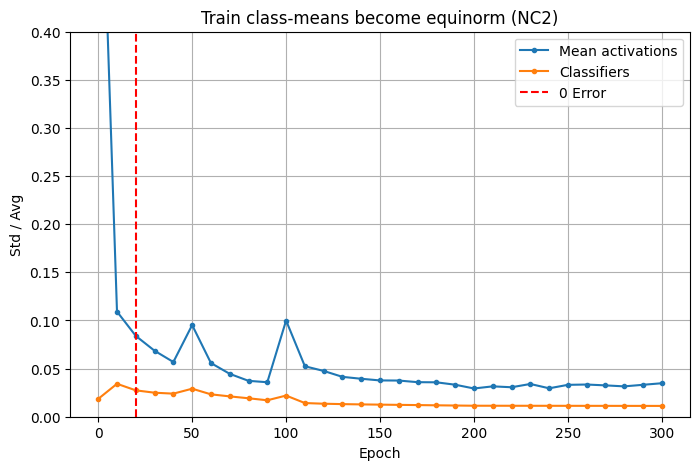

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,1], 'o-', markersize=3, label="Mean activations")
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,2], 'o-', markersize=3, label="Classifiers")
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Train class-means become equinorm (NC2)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Std / Avg")
ax.set_ylim((0.0, 0.4))
ax.grid()
ax.legend()
plt.show()

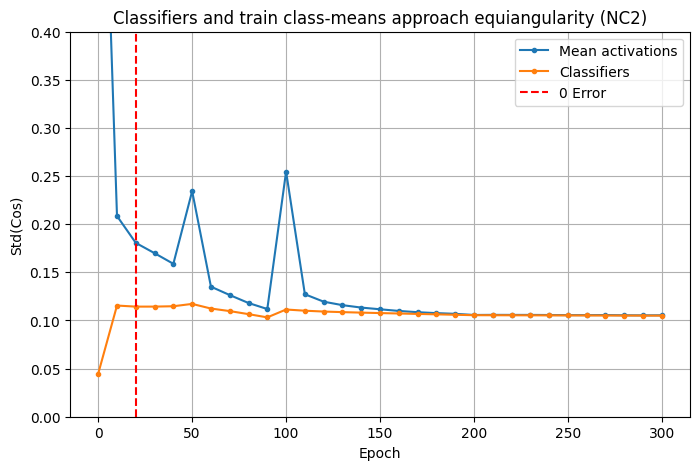

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,3], 'o-', markersize=3, label="Mean activations")
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,4], 'o-', markersize=3, label="Classifiers")
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Classifiers and train class-means approach equiangularity (NC2)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Std(Cos)")
ax.set_ylim((0.0, 0.4))
ax.grid()
ax.legend()
plt.show()

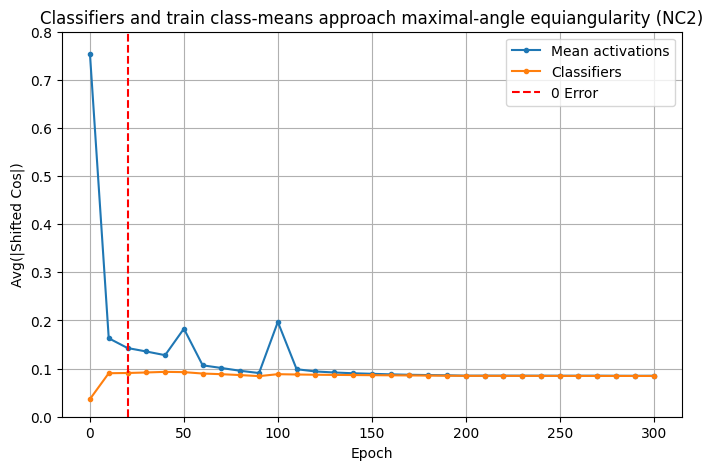

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,5], 'o-', markersize=3, label="Mean activations")
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,6], 'o-', markersize=3, label="Classifiers")
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Classifiers and train class-means approach maximal-angle equiangularity (NC2)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg(|Shifted Cos|)")
ax.set_ylim((0.0, 0.8))
ax.grid()
ax.legend()
plt.show()

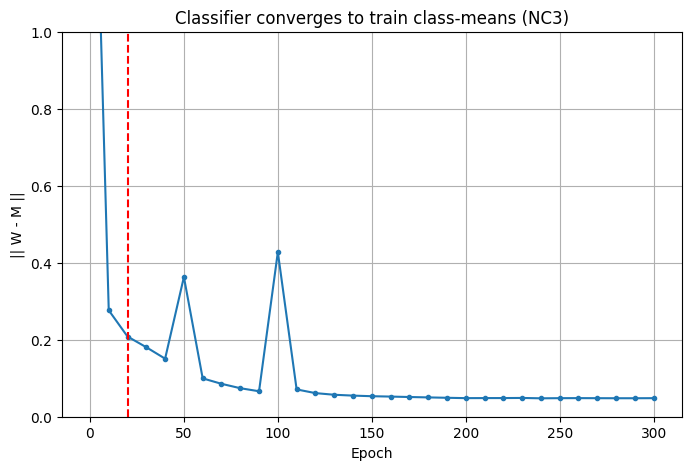

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,7], 'o-', markersize=3)
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Classifier converges to train class-means (NC3)")
ax.set_xlabel("Epoch")
ax.set_ylabel("|| W - M ||")
ax.set_ylim((0.0, 1.0))
ax.grid()
plt.show()

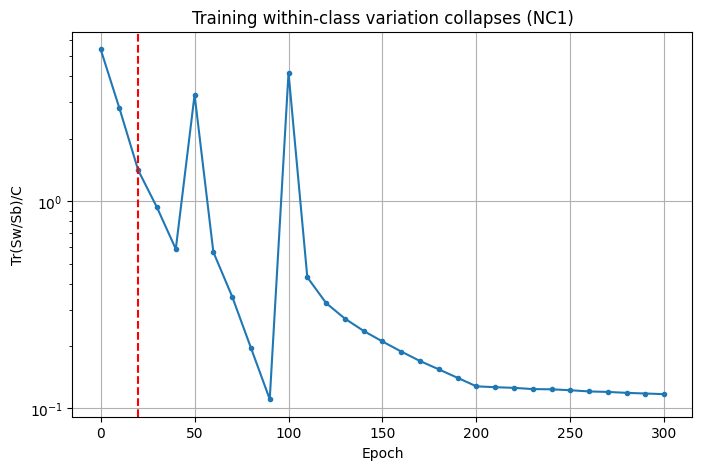

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,0], 'o-', markersize=3)
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Training within-class variation collapses (NC1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Tr(Sw/Sb)/C")
ax.set_yscale("log")
ax.grid()
plt.show()

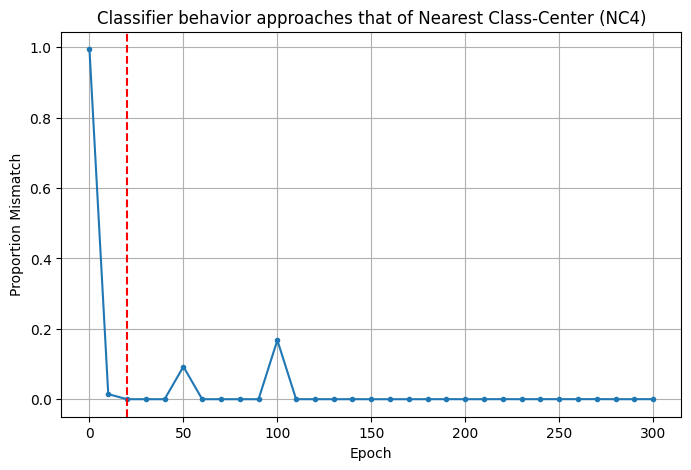

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), neural_collapse_indicators[:,8], 'o-', markersize=3)
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Classifier behavior approaches that of Nearest Class-Center (NC4)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Proportion Mismatch")
ax.grid()
plt.show()

Overall, we achieved to replicate the results of Papyan et. al. (2020), where all indicators of Neural Collapse decrease during the model training. Although two minor differences can be noted. First, our model reaches the terminal phase of training faster than theirs, in only about 20 epochs. Second, the indicators of NC2, showing how the train-class means converge to the simplex, seem to take more time to converge to 0. We suppose that this difference is due to the fact that we did not replicate exactly the methodology of Papyan et. al. (2020) in terms of networks architecture and optimization. The value of the learning rate they used for SGD is not known, and a higher rate could lead to a faster convergence. Also, they used ResNet50 while we used ResNet18, and the number of parameters could have an influence on the neural collapse phenomenon.

# Question 5: Study NC5

NC5 is a fifth property of neural collapse, theorized by Ben Ammar et. al. (2024). It states that as the training procedure advances, OOD and ID data tend to become indreasingly more orthogonal to each others. To visualize this phenomenon, Ben Ammar et. al. (2024) study the following indicator:
$$\operatorname{NC5} = \frac{1}{C} \sum_{c=1}^C \left| \frac{\langle \mu_c, \mu^{OOD} \rangle}{\|\mu_c\|_2 \|\mu^{OOD}\|_2}\right|$$
where $\mu_c$ are the same as previously, and $\mu^{OOD}$ is the mean of the features $h_\omega(x)$ over the whole OOD dataset.

As we did in question 4, we implement a function computing this indicator, and then train again the model, evaluating this indicator every 10 epochs.

In [26]:
def evaluate_NC5(model, train_loader, ood_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    C = model.fc.out_features # Number of classes
    p = model.fc.in_features # Size of features

    # 1. ADDING A HOOK TO THE MODEL TO ACCESS FEATURES
    activations = {}
    def get_activation():
        def hook(model, input, output):
            activations["features"] = output.detach().squeeze(-1).squeeze(-1)
        return hook
    hook_handle = model.avgpool.register_forward_hook(get_activation())

    # 2. BROWSE THE TRAINING DATASET AND KEEP USEFUL STATISTICS
    Nc = torch.zeros((C), device=device)
    sum_h = torch.zeros((C, p), device=device)
    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            model(inputs)
            features = activations["features"]

            Nc.index_add_(0, labels, torch.ones((labels.shape[0]), device=device))
            sum_h.index_add_(0, labels, features)
    
    Mu_c = sum_h / Nc[:, None] #shape=(C,p)

    # 3. BROWSE THE OOD DATASET AND KEEP USEFUL STATISTICS
    sum_h_ood = torch.zeros(p, device=device)
    with torch.no_grad():
        for inputs, labels in ood_loader:
            inputs, _ = inputs.to(device), labels.to(device)
            model(inputs)
            features = activations["features"]

            sum_h_ood += torch.sum(features, dim=0)
    
    Mu_OOD = sum_h_ood / len(ood_loader.dataset)

    # 4. COMPUTE NC5
    normalized_Mu_c = Mu_c / torch.norm(Mu_c, dim=1, keepdim=True)
    normalized_Mu_OOD = Mu_OOD / torch.norm(Mu_OOD)
    nc5 = float(1/C * torch.sum(normalized_Mu_c * normalized_Mu_OOD))

    hook_handle.remove()

    return nc5

In [27]:
num_epochs = 300

model = empty_resnet_model()
criterion = nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.SGD(model.parameters(), lr=7e-4, momentum=0.9, weight_decay=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 200], gamma=0.1)

near_ood_nc5 = np.zeros(31)
far_ood_nc5 = np.zeros(31)

for epoch in tqdm(range(num_epochs)):

    # Every 10 epochs, evaluate the model
    if epoch % 10 == 0:
        near_ood_nc5[int(epoch//10)] = evaluate_NC5(model, train_loader, near_ood_loader)
        far_ood_nc5[int(epoch//10)] = evaluate_NC5(model, train_loader, far_ood_loader)

    model.train()
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()

near_ood_nc5[30] = evaluate_NC5(model, train_loader, near_ood_loader)
far_ood_nc5[30] = evaluate_NC5(model, train_loader, far_ood_loader)

100%|██████████| 300/300 [3:35:36<00:00, 43.12s/it]


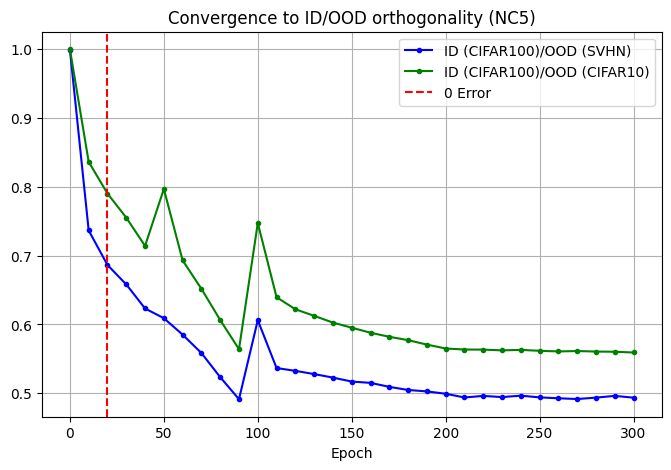

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, 310, 10), far_ood_nc5, 'bo-', markersize=3, label="ID (CIFAR100)/OOD (SVHN)")
ax.plot(np.arange(0, 310, 10), near_ood_nc5, 'go-', markersize=3, label="ID (CIFAR100)/OOD (CIFAR10)")
ax.axvline(epoch_0_error, color='red', linestyle='--', label="0 Error")
ax.set_title("Convergence to ID/OOD orthogonality (NC5)")
ax.set_xlabel("Epoch")
ax.grid()
ax.legend()
plt.show()

We observe similar results to what has been found by Ben Ammar, et. al. (2024): as training progresses, the clusters of OOD data become increasingly orthogonal to the configuration adopted by ID data, espeically for the far-OOD dataset (SVHN).


# Question 6: Implement the NECO method

The NECO Method is an OOD detection method proposed by Ben Ammar et. al. (2024) and based on the observation of the NC5 phenomenon. Their OOD score for an image $x$ is
$$\operatorname{NECO}(x) = \frac{\|P h_\omega(x)\|}{\|h_\omega(x)\|} \Big( \times \operatorname{MaxLogit}(x)\Big)$$
where $h_\omega(x)$ is the vector of features, obtained from running all the network except the last layer on $x$, and $P$ is the projection matrix on the biggest $d$ eigenvectors (we have used a similar matrix when defining the ViM score), and $\operatorname{MaxLogit}(x)$ is the Max Logit score used previously.

It is not clear whether the method used in the paper experiments is the version with or without the calibration with the max logits. Therefore, we are going to implement both and compare their performance.

In the following, we are going to implement the NECO score and run it on the same ID and OOD datasets as previously. We will use the same model as for the other methods of question 3, trained on 100 epochs.

In [29]:
model = empty_resnet_model()
state_dict = torch.load('resnet18_cifar100_final.pth', map_location=device)
model.load_state_dict(state_dict)
model.to(device)

In [30]:
# ----- NECO IMPLEMENTATION -----
d = 100
p = model.fc.in_features
N = len(train_loader.dataset)

hook_handle = model.avgpool.register_forward_hook(get_activation())

sum_h = torch.zeros((p), device=device)
sum_hhT = torch.zeros((p,p), device=device)

# We browse the training dataset, in order to compute P
model.eval()
with torch.no_grad():
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        model(inputs)
        features = activations["features"]
        sum_h += torch.sum(features, dim=0)
        sum_hhT += torch.sum(features[:,:,None] * features[:,None,:], dim=0)

hook_handle.remove()

train_features_cov_matrix = 1/N * sum_hhT - 1/N**2 * sum_h[None,:] * sum_h[:,None]
eigenvalues, eigenvectors = torch.linalg.eigh(train_features_cov_matrix)
P = eigenvectors[:,-d:]

def neco(logits, features):
    projection = features @ P
    neco_score = torch.norm(projection, dim=1) / torch.norm(features, dim=1)
    return neco_score

def neco_times_maxlogits(logits, features):
    projection = features @ P
    neco_score = torch.norm(projection, dim=1) / torch.norm(features, dim=1)
    max_logits = torch.max(logits, dim=1).values
    return neco_score * max_logits

100%|██████████| 10/10 [00:03<00:00,  3.31it/s]


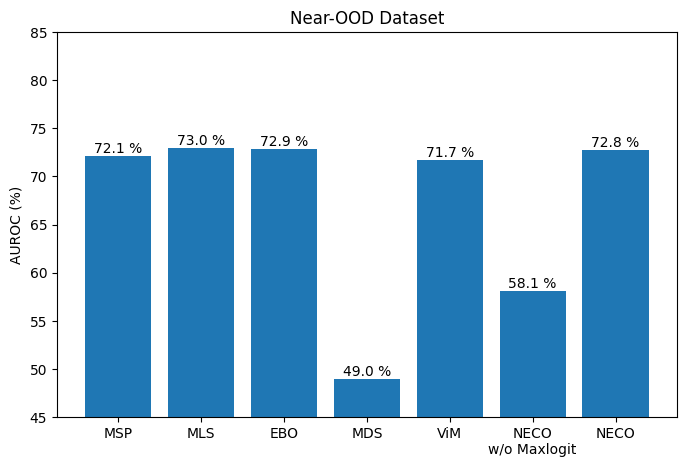

In [31]:
aurocs = [72.1, 73.0, 72.9, 49.0, 71.7]
for method in [neco, neco_times_maxlogits]:
    auroc, _ = evaluate_ood_detection(model, id_loader, near_ood_loader, method, visualize_roc=False)
    aurocs.append(auroc*100)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(["MSP", "MLS", "EBO", "MDS", "ViM", "NECO\nw/o Maxlogit", "NECO"], aurocs)
for (i, bar) in enumerate(bars): plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{aurocs[i]:.1f} %", ha='center', va='bottom')
ax.set_ylabel("AUROC (%)")
ax.set_title("Near-OOD Dataset")
ax.set_ylim((45, 85))
plt.show()

100%|██████████| 26/26 [00:05<00:00,  4.39it/s]


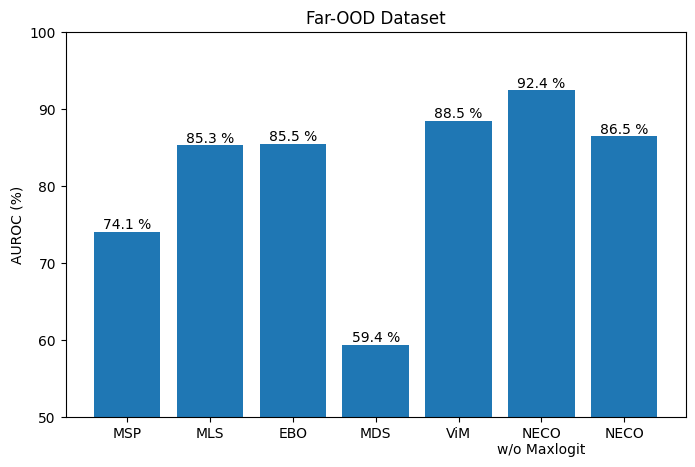

In [32]:
aurocs = [74.1, 85.3, 85.5, 59.4, 88.5]
for method in [neco, neco_times_maxlogits]:
    auroc, _ = evaluate_ood_detection(model, id_loader, far_ood_loader, method, visualize_roc=False)
    aurocs.append(auroc*100)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(["MSP", "MLS", "EBO", "MDS", "ViM", "NECO\nw/o Maxlogit", "NECO"], aurocs)
for (i, bar) in enumerate(bars): plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{aurocs[i]:.1f} %", ha='center', va='bottom')
ax.set_ylabel("AUROC (%)")
ax.set_title("Far-OOD Dataset")
ax.set_ylim((50,100))
plt.show()

For the near-OOD dataset (CIFAR-10), the NECO method does not outperform existant methods. The method without MaxLogits underperforms compared to all other methods except Mahalanobis, while the method with Max Logits is a little bit below the original Max Logits (MLS) method. The performance of the latter is thus only due to the max logits, and not to the NECO score. These results are in line with those of Ben Ammar et. al. (2024), where the NECO method has only an auroc of 70.26 while MLS has an AUROC score of 75.44, when the datastes are CIFAR-100/CIFAR-10.

On the far-OOD datset (SVHN), however, NECO without max logits beats all other methods with an AUROC score of 92.4. This is in line with the results of Ben Ammar et. al. (2024) who found that NECO was outperforming all other baseline methods, including ViM and MLS.

# References

Ben Ammar, et. al. "NECO: Neural Collapse Based Out-of-Distribution Detection" in *ICLR* (2024)

Ben Ammar, et. al. "Double Descent Meets Out-of-Distribution Detection: Theoretical Insights and Empirical Analysis on the Role of Model Complexity" in *NeurIPS* (2025)

Papyan, et. al. "Prevalence of Neural Collapse during the terminal phase of deep learning training" in *Proceedings of the National Academy of Sciences* (2020)

Wang, et. al. "ViM: Out-Of-Distribution with Virtual-logit Matching" in *CVPR* (2022)

Zhang, et. al. "OpenOOD v1.5: Enhanced Benchmark for Out-of-Distribution Detection" in *Journal of Data-centric Machine Learning Research* (2024)